In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import os
from matplotlib import gridspec
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.size'] = 11
mpl.rcParams['font.family'] = 'sans-serif'
# Remove top & right spines from every plot
mpl.rcParams['axes.spines.top']   = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.linewidth']      = 0.25   # all spine lines
mpl.rcParams['xtick.major.width']   = 0.25
mpl.rcParams['ytick.major.width']   = 0.25
mpl.rcParams['xtick.minor.width']   = 0.25
mpl.rcParams['ytick.minor.width']   = 0.25

# ── Fresh results ────────────────────────────────────────────────────────────
# Combined table for all cohorts incl. GEL (anonymised GEL_N IDs, all 56 GEL).
# Reproduce from the published supplement (Table S2, HRDTimer estimates)
EXCEL_PATH  = "../supplemental_tables_v2/SupTable8_HRDTimer_estimates.xlsx"
S2_INV = {"sample_id": "sample", "subtype": "type", "is_WGD": "isWGD", "tumour_grade": "grade", "clinical_stage": "final_stage_main", "hrd_origin": "hrd.origin", "hrd_origin_with_methylation": "hrd.origin.with.meth", "HRD_genotype": "genotype", "CHORD_genotype": "chord.genotype", "TP53_mutated": "isTp53Mut", "PALB2_mutated": "isPALB2Mut", "HRDetect_score": "HRDetect", "is_HRD": "HRDetect.isHRD", "T_stage": "T_STAGE", "tumour_size_mm": "tum.size.mm", "age_band_label": "age_band", "BRCA1_monoallelic": "isBRCA1Monoallelic", "BRCA1_biallelic": "isBRCA1Biallelic", "BRCA2_monoallelic": "isBRCA2Monoallelic", "BRCA2_biallelic": "isBRCA2Biallelic", "BRCA1_promoter_methylation_class": "BRCA1_PromMetClass", "RAD51C_promoter_methylation_class": "RAD51C_PromMetClass", "HRDTime_molecular": "HRDTime", "HRDTime_molecular_ci_lo": "HRDTime_ci_lo", "HRDTime_molecular_ci_hi": "HRDTime_ci_hi", "HRDTime_molecular_IQR_lo": "HRDTime_ci_IQR_lo", "HRDTime_molecular_IQR_hi": "HRDTime_ci_IQR_hi", "WGDTime_molecular": "WGDTime", "WGDTime_molecular_ci_lo": "WGDTime_ci_lo", "WGDTime_molecular_ci_hi": "WGDTime_ci_hi", "WGDTime_molecular_IQR_lo": "WGDTime_ci_IQR_lo", "WGDTime_molecular_IQR_hi": "WGDTime_ci_IQR_hi", "HRD_duration_median_yrs": "HRD_Duration_median", "HRD_duration_ci05_yrs": "HRD_Duration_ci05", "HRD_duration_ci95_yrs": "HRD_Duration_ci95", "TS_duration_median_yrs": "TS_Duration_median", "TS_duration_ci05_yrs": "TS_Duration_ci05", "TS_duration_ci95_yrs": "TS_Duration_ci95", "HRD_onset_age_median": "HRD_crossing_age_median", "HRD_onset_age_ci05": "HRD_crossing_age_ci05", "HRD_onset_age_ci95": "HRD_crossing_age_ci95", "TS_onset_age_median": "TS_crossing_age_median", "TS_onset_age_ci05": "TS_crossing_age_ci05", "TS_onset_age_ci95": "TS_crossing_age_ci95"}
# PCAWG Ovary timing results (Table S10).
OVARY_XLSX  = "../supplemental_tables_v2/SupTable9_Ovary_HRDTime_WGDTime.xlsx"
OUT_DIR     = "../output/Fig2_HRDTime_WGDTime"
os.makedirs(OUT_DIR, exist_ok=True)
OUTPUT_PATH = f"{OUT_DIR}/Fig2_HRDTime_WGDTime_all_cohorts.pdf"

# Figure width capped at A4 landscape (11.69 in).
A4_LANDSCAPE_W = 11.69

In [2]:
# ── Load ALL cohorts (INFORM, SCANB, PCAWG, GEL) from the fresh combined table ─
df = pd.read_excel(EXCEL_PATH, sheet_name='HRDTimer Estimates').rename(columns=S2_INV)
df = df[df['scaled_SBS1'].notna()].reset_index(drop=True)   # SBS1-timing analysis cohort
df['subtype']    = df['type'].fillna('other/unknown')
df['display_id'] = df['sample']          # GEL rows are already anonymised (GEL_N)

KEEP_COLS = [
    'display_id', 'cohort', 'subtype',
    'HRDTime', 'HRDTime_ci_lo', 'HRDTime_ci_hi', 'HRDTime_ci_IQR_lo', 'HRDTime_ci_IQR_hi',
    'WGDTime', 'WGDTime_ci_lo', 'WGDTime_ci_hi', 'WGDTime_ci_IQR_lo', 'WGDTime_ci_IQR_hi',
]
df_all = (
    df[KEEP_COLS]
    .dropna(subset=['HRDTime', 'WGDTime'])
    .reset_index(drop=True)
)

print(f"Total samples: {len(df_all)}")
print(df_all.groupby(['cohort', 'subtype']).size().to_string())

Total samples: 115
cohort  subtype      
GEL     ER+              13
        HER2+             3
        TN               15
        other/unknown    25
INFORM  ER+               2
        TN                4
PCAWG   ER+               9
        TN               11
SCANB   TN               33


In [3]:
# ── Sort: cohort order → subtype order → HRDTime ascending ──────────────────
COHORT_ORDER  = ['INFORM', 'SCANB', 'PCAWG', 'GEL']
SUBTYPE_ORDER = ['ER+', 'TN', 'HER2+', 'other/unknown']

df_all['_co'] = df_all['cohort'].map({c: i for i, c in enumerate(COHORT_ORDER)}).fillna(99)
df_all['_st'] = df_all['subtype'].map({s: i for i, s in enumerate(SUBTYPE_ORDER)}).fillna(99)
df_all = (
    df_all.sort_values(['_co', '_st', 'HRDTime'])
          .drop(columns=['_co', '_st'])
          .reset_index(drop=True)
)
df_all['x'] = np.arange(len(df_all))

cohort_col  = df_all['cohort'].tolist()
subtype_col = df_all['subtype'].tolist()

# Cohort boundaries (dashed black) and subtype boundaries within cohorts (dotted grey)
cohort_sep_lines  = [i - 0.5 for i in range(1, len(cohort_col))
                     if cohort_col[i] != cohort_col[i-1]]
subtype_sep_lines = [i - 0.5 for i in range(1, len(subtype_col))
                     if subtype_col[i] != subtype_col[i-1]
                     and cohort_col[i] == cohort_col[i-1]]   # only within-cohort

# Cohort label centres (top row)
cohort_pos = {}
for i, c in enumerate(cohort_col):
    cohort_pos.setdefault(c, []).append(i)
cohort_labels = [(np.mean(pos), c) for c, pos in cohort_pos.items()]

# Subtype label centres within each cohort (bottom row)
subtype_in_cohort_pos = {}
for i, (c, s) in enumerate(zip(cohort_col, subtype_col)):
    subtype_in_cohort_pos.setdefault((c, s), []).append(i)
subtype_in_cohort_labels = [(np.mean(pos), s) for (c, s), pos in subtype_in_cohort_pos.items()]

print("Samples per cohort:", {c: len(p) for c, p in cohort_pos.items()})

Samples per cohort: {'INFORM': 6, 'SCANB': 33, 'PCAWG': 20, 'GEL': 56}


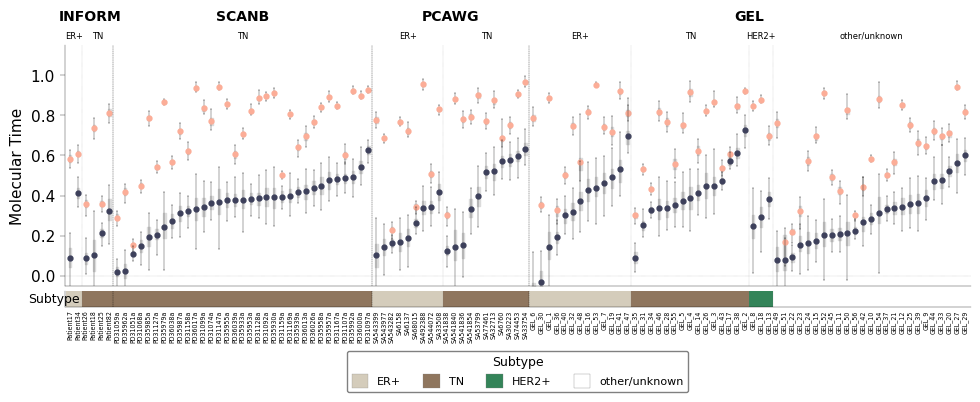

Saved to ../output/fig2/Fig2_HRDTime_WGDTime_all_cohorts.pdf


In [4]:
# ── Colours ─────────────────────────────────────────────────────────────────
HRD_COLOR  = '#3d405b'     # dark navy
WGD_COLOR  = '#fcad97'     # salmon/peach
IQR_COLOR  = '#dbdbdb'     # light grey fill
ERR_HRD    = '#3d405b'
ERR_WGD    = '#c47a5e'

SUBTYPE_COLORS = {
    'ER+':           '#c2b79e',
    'TN':            '#603c1a',
    'HER2+':         '#0b6b37',
    'other/unknown': '#ffffff',
}
SUBTYPE_ALPHA = {
    'ER+':           0.70,
    'TN':            0.70,
    'HER2+':         0.83,
    'other/unknown': 1.00,
}

# ── Figure layout (width = A4 landscape; short/wide proportions) ──────────────
n         = len(df_all)
fig_width = A4_LANDSCAPE_W
fig, (ax, ax_bar) = plt.subplots(
    2, 1,
    figsize=(fig_width, 3.4),
    gridspec_kw={'height_ratios': [15, 1], 'hspace': 0.04},
    sharex=False,
)

MS  = 3.5    # marker size
ELW = 0.25   # 95% CI line width
CS  = 1.0    # cap size

# ── IQR shaded rectangles (behind everything) ────────────────────────────────
for _, r in df_all.iterrows():
    xc = r['x']
    hw = 0.15
    for time_col, lo_col, hi_col in [
        ('HRDTime', 'HRDTime_ci_IQR_lo', 'HRDTime_ci_IQR_hi'),
        ('WGDTime', 'WGDTime_ci_IQR_lo', 'WGDTime_ci_IQR_hi'),
    ]:
        ax.fill_between(
            [xc - hw, xc + hw],
            [r[time_col] - r[lo_col]] * 2,
            [r[time_col] + r[hi_col]] * 2,
            color=IQR_COLOR, alpha=1, zorder=0,
        )

# ── Error bars + dots ────────────────────────────────────────────────────────
ax.errorbar(
    df_all['x'], df_all['WGDTime'],
    yerr=[df_all['WGDTime_ci_lo'], df_all['WGDTime_ci_hi']],
    fmt='o', color=WGD_COLOR, ecolor='black',
    elinewidth=ELW, capsize=CS, capthick=0.25, markersize=MS, zorder=2, label='WGDTime',
)
ax.errorbar(
    df_all['x'], df_all['HRDTime'],
    yerr=[df_all['HRDTime_ci_lo'], df_all['HRDTime_ci_hi']],
    fmt='o', color=HRD_COLOR, ecolor='black',
    elinewidth=ELW, capsize=CS, capthick=0.25, markersize=MS, zorder=3, label='HRDTime',
)

# ── Subtype separators (thin dotted grey, within cohorts) ────────────────────
for sl in subtype_sep_lines:
    ax.axvline(sl, color='grey', linestyle=':', linewidth=0.25, zorder=4)

# ── Cohort separators (dashed black) ────────────────────────────────────────
for sl in cohort_sep_lines:
    ax.axvline(sl, color='black', linestyle='--', linewidth=0.25, zorder=5)

ax.set_ylim(-0.05, 1.15)

# Top row: cohort labels
for mid, c in cohort_labels:
    ax.text(mid, 1.09, c, ha='center', va='bottom', fontsize=10, fontweight='bold',
            transform=ax.get_xaxis_transform())

# Bottom row: subtype labels within each cohort
for mid, s in subtype_in_cohort_labels:
    ax.text(mid, 1.02, s, ha='center', va='bottom', fontsize=6,
            transform=ax.get_xaxis_transform())

ax.axhline(0, color='grey', linestyle=':', linewidth=0.25)
ax.set_ylabel('Molecular Time', fontsize=11)
ax.set_xlim(-0.7, n - 0.3)
ax.set_xticks([])
ax.spines['bottom'].set_visible(True)  # keep x spine on top panel

# ── Subtype annotation bar ───────────────────────────────────────────────────
for _, r in df_all.iterrows():
    color = SUBTYPE_COLORS.get(r['subtype'], SUBTYPE_COLORS['other/unknown'])
    ax_bar.add_patch(mpatches.Rectangle(
        (r['x'] - 0.5, 0), 1, 1,
        color=color, alpha=SUBTYPE_ALPHA.get(r['subtype'], 1.0), linewidth=0,
    ))

for sl in subtype_sep_lines:
    ax_bar.axvline(sl, color='grey', linestyle=':', linewidth=0.25)
for sl in cohort_sep_lines:
    ax_bar.axvline(sl, color='black', linestyle='--', linewidth=0.25)

ax_bar.set_xlim(-0.7, n - 0.3)
ax_bar.set_ylim(0, 1)
ax_bar.set_yticks([])
ax_bar.set_ylabel('Subtype', fontsize=9, rotation=0, labelpad=38, va='center')
ax_bar.yaxis.set_label_coords(-0.012, 0.5)

ax_bar.set_xticks(df_all['x'])
ax_bar.set_xticklabels(df_all['display_id'], rotation=90, fontsize=4.5)
ax_bar.tick_params(axis='x', length=0, pad=2)

# ── Bottom legend ────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=SUBTYPE_COLORS[s], alpha=SUBTYPE_ALPHA[s],
                   edgecolor='grey', linewidth=0.25, label=s)
    for s in ['ER+', 'TN', 'HER2+', 'other/unknown']
]
ax_bar.legend(
    handles=legend_patches,
    title='Subtype', title_fontsize=9,
    loc='upper center',
    bbox_to_anchor=(0.5, -2.4),
    ncol=4, fontsize=8,
    frameon=True, framealpha=1, edgecolor='grey',
    handlelength=1.5, handleheight=1.5,
)

plt.savefig(OUTPUT_PATH, format='pdf', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved to {OUTPUT_PATH}")

Breast - HRDTime: Median=0.34, IQR=(0.20-0.44), n=115
Breast - WGDTime: Median=0.75, IQR=(0.57-0.85), n=115
Ovary - HRDTime: Median=0.29, IQR=(0.24-0.48), n=27
Ovary - WGDTime: Median=0.50, IQR=(0.31-0.85), n=27


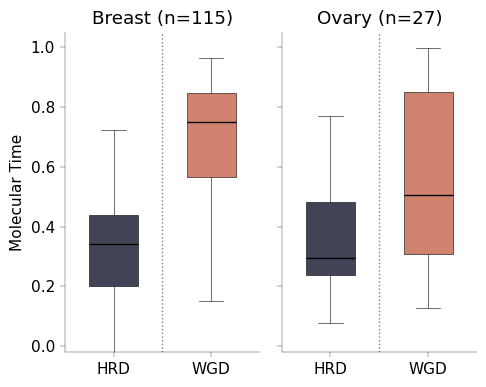

Saved to output/Fig2_Breast_Ovary_HRD_WGD_boxplot.pdf


In [5]:
# ── Breast vs Ovary HRDTime/WGDTime boxplots (no clinical features) ───────────
import seaborn as sns

BOX_HRD = '#3d405b'   # dark navy
BOX_WGD = '#e07a5f'   # salmon

# Breast = all breast cohorts (INFORM + SCANB + PCAWG + GEL) from df_all
breast = df_all[['display_id', 'HRDTime', 'WGDTime']].copy()
breast = breast.rename(columns={'display_id': 'ID'})

# Ovary = PCAWG Ovary timing results
ovary = pd.read_excel(OVARY_XLSX, sheet_name='Ovary').rename(columns={'display_id': 'ID'})[['ID', 'HRDTime', 'WGDTime']].copy()

panels = {'Breast': breast, 'Ovary': ovary}

fig, axes = plt.subplots(1, 2, figsize=(5, 4), sharey=True)
for ax, cancer in zip(axes, ['Breast', 'Ovary']):
    df = panels[cancer]
    long = pd.melt(df, id_vars='ID', value_vars=['HRDTime', 'WGDTime'],
                   var_name='TimeType', value_name='Time')

    # Medians and IQRs
    for tt, g in long.groupby('TimeType'):
        q1, q3 = g['Time'].quantile(0.25), g['Time'].quantile(0.75)
        print(f"{cancer} - {tt}: Median={g['Time'].median():.2f}, "
              f"IQR=({q1:.2f}-{q3:.2f}), n={len(g)}")

    sns.boxplot(
        data=long, x='TimeType', y='Time',
        hue='TimeType', palette={'HRDTime': BOX_HRD, 'WGDTime': BOX_WGD},
        width=0.5, fliersize=2,
        boxprops=dict(edgecolor='black', linewidth=0.4),
        whiskerprops=dict(color='black', linewidth=0.4),
        capprops=dict(color='black', linewidth=0.4),
        medianprops=dict(color='black'),
        flierprops=dict(markeredgecolor='black', linewidth=0.5),
        dodge=False, ax=ax,
    )
    ax.legend([], [], frameon=False)
    ax.axvline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f"{cancer} (n={df['ID'].nunique()})")
    ax.set_xlabel('')
    ax.set_ylabel('Molecular Time' if cancer == 'Breast' else '')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['HRD', 'WGD'])
    ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/Fig2_Breast_Ovary_HRD_WGD_boxplot.pdf", format='pdf', bbox_inches='tight')
plt.show()


GEL - HRDTime: Median=0.34, IQR=(0.21-0.45), n=56
GEL - WGDTime: Median=0.71, IQR=(0.53-0.82), n=56
INFORM - HRDTime: Median=0.16, IQR=(0.09-0.30), n=6
INFORM - WGDTime: Median=0.60, IQR=(0.42-0.70), n=6
PCAWG - HRDTime: Median=0.34, IQR=(0.16-0.52), n=20
PCAWG - WGDTime: Median=0.77, IQR=(0.69-0.88), n=20
SCANB - HRDTime: Median=0.38, IQR=(0.31-0.42), n=33
SCANB - WGDTime: Median=0.79, IQR=(0.60-0.88), n=33


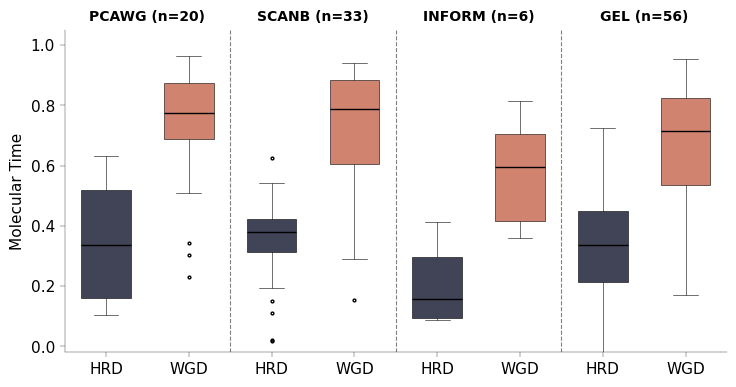

Saved to output/Fig2_cohort_HRD_WGD_boxplot_withGEL.pdf


In [6]:
# ── Per-cohort HRD vs WGD boxplots, now including GEL ─────────────────────────
# Reuses df_all (INFORM, SCANB, PCAWG, GEL) assembled above; same style as the
# original breast-cohort comparison, with GEL added as a fourth cohort.
BOX_HRD = '#3d405b'
BOX_WGD = '#e07a5f'
COHORT_PLOT_ORDER = ['PCAWG', 'SCANB', 'INFORM', 'GEL']

cohorts = df_all[['display_id', 'cohort', 'HRDTime', 'WGDTime']].copy()
cohort_long = pd.melt(cohorts, id_vars=['display_id', 'cohort'],
                      value_vars=['HRDTime', 'WGDTime'],
                      var_name='TimeType', value_name='Time')

# Medians and IQRs per cohort and time type
for (c, tt), g in cohort_long.groupby(['cohort', 'TimeType']):
    q1, q3 = g['Time'].quantile(0.25), g['Time'].quantile(0.75)
    print(f"{c} - {tt}: Median={g['Time'].median():.2f}, "
          f"IQR=({q1:.2f}-{q3:.2f}), n={len(g)}")

# x ordering: HRD then WGD within each cohort
cohort_long['x_label'] = cohort_long['TimeType'] + '\n' + cohort_long['cohort']
x_order, palette = [], {}
for c in COHORT_PLOT_ORDER:
    for tt, col in [('HRDTime', BOX_HRD), ('WGDTime', BOX_WGD)]:
        lab = f'{tt}\n{c}'
        x_order.append(lab)
        palette[lab] = col

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.boxplot(
    data=cohort_long, x='x_label', y='Time',
    hue='x_label', palette=palette, order=x_order,
    width=0.6, fliersize=2,
    boxprops=dict(edgecolor='black', linewidth=0.4),
    whiskerprops=dict(color='black', linewidth=0.4),
    capprops=dict(color='black', linewidth=0.4),
    medianprops=dict(color='black'),
    flierprops=dict(markeredgecolor='black', linewidth=0.5),
    dodge=False, ax=ax,
)
ax.legend([], [], frameon=False)

# Dashed separators between cohorts; cohort labels on top
n_per = {c: cohort_long[cohort_long['cohort'] == c]['display_id'].nunique()
         for c in COHORT_PLOT_ORDER}
for i in range(1, len(COHORT_PLOT_ORDER)):
    ax.axvline(i * 2 - 0.5, color='gray', linestyle='--', linewidth=0.8)
for i, c in enumerate(COHORT_PLOT_ORDER):
    ax.text(i * 2 + 0.5, 1.02, f"{c} (n={n_per[c]})",
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            transform=ax.get_xaxis_transform())

ax.set_xticks(range(len(x_order)))
ax.set_xticklabels(['HRD', 'WGD'] * len(COHORT_PLOT_ORDER))
ax.set_xlabel('')
ax.set_ylabel('Molecular Time')
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/Fig2_cohort_HRD_WGD_boxplot_withGEL.pdf", format='pdf', bbox_inches='tight')
plt.show()


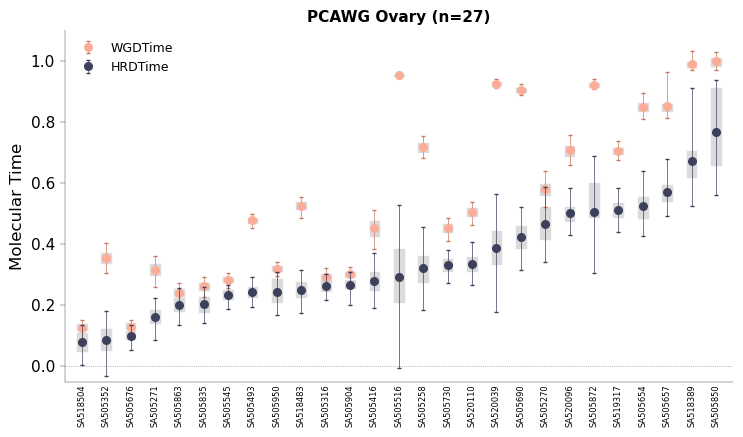

Saved to output/Fig2_Ovary_HRD_WGD_lollipop.pdf


In [7]:
# ── Per-sample lollipop for PCAWG Ovary (same encoding as the main figure) ────
# Single cohort, no clinical subtypes → no subtype annotation bar.
HRD_COLOR = '#3d405b'; WGD_COLOR = '#fcad97'
IQR_COLOR = '#dbdbdb'; ERR_HRD = '#3d405b'; ERR_WGD = '#c47a5e'

ov = pd.read_excel(OVARY_XLSX, sheet_name='Ovary')
ov['sample.display'] = ov['display_id']

ov = ov.sort_values('HRDTime').reset_index(drop=True)
ov['x'] = np.arange(len(ov))
n_ov = len(ov)

fig, ax = plt.subplots(figsize=(min(A4_LANDSCAPE_W, max(6, n_ov * 0.28)), 4.5))

# IQR shaded rectangles (behind everything)
for _, r in ov.iterrows():
    xc, hw = r['x'], 0.20
    for t, lo, hi in [('HRDTime', 'HRDTime_ci_IQR_lo', 'HRDTime_ci_IQR_hi'),
                      ('WGDTime', 'WGDTime_ci_IQR_lo', 'WGDTime_ci_IQR_hi')]:
        ax.fill_between([xc - hw, xc + hw],
                        [r[t] - r[lo]] * 2, [r[t] + r[hi]] * 2,
                        color=IQR_COLOR, alpha=1, zorder=0)

# Error bars + dots
ax.errorbar(ov['x'], ov['WGDTime'],
            yerr=[ov['WGDTime_ci_lo'], ov['WGDTime_ci_hi']],
            fmt='o', color=WGD_COLOR, ecolor=ERR_WGD,
            elinewidth=0.5, capsize=1.5, markersize=5.5, zorder=2, label='WGDTime')
ax.errorbar(ov['x'], ov['HRDTime'],
            yerr=[ov['HRDTime_ci_lo'], ov['HRDTime_ci_hi']],
            fmt='o', color=HRD_COLOR, ecolor=ERR_HRD,
            elinewidth=0.5, capsize=1.5, markersize=5.5, zorder=3, label='HRDTime')

ax.axhline(0, color='grey', linestyle=':', linewidth=0.5)
ax.set_ylim(-0.05, 1.10)
ax.set_xlim(-0.7, n_ov - 0.3)
ax.set_ylabel('Molecular Time', fontsize=12)
ax.set_title(f'PCAWG Ovary (n={n_ov})', fontsize=11, fontweight='bold')
ax.set_xticks(ov['x'])
ax.set_xticklabels(ov['sample.display'], rotation=90, fontsize=6)
ax.tick_params(axis='x', length=0, pad=2)
ax.legend(loc='upper left', frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/Fig2_Ovary_HRD_WGD_lollipop.pdf", format='pdf', bbox_inches='tight', dpi=150)
plt.show()
